In [13]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

import cellxgene_census

# adata = read_anndata(
#     '/Volumes/Extreme SSD/BA_datasets/Consortium2022.h5ad',
#     # X='X',
#     obs='obs',
#     var='var',
#     obsm='obsm',
# ) it was in fact the wrong data..

# dataset_name = 'Consoritum2022_open_problems'
# file_path = f'~/Downloads/{dataset_name}.h5ad'

# url = get_cxg_url(
#     collection_id="e5f58829-1a66-40b5-a624-9046778e74f5",
#     dataset_id="53d208b0-2cfd-4366-9866-c3c6114081bc"
# )

#this is the right one
# cellxgene_census.download_source_h5ad(
#     dataset_id='53d208b0-2cfd-4366-9866-c3c6114081bc',
#     census_version="2023-07-25",
#     to_path="/Users/seohyon/Downloads/Consoritum2022_open_problems.h5ad"  # or wherever you want the data to be
# )

    
    

In [14]:
adata = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Consoritum2022_open_problems.h5ad',
    X='X',
    obs='obs',
    var='var',
    obsm='obsm',
    # obsp='obsp',
    # dask=True,
    # backed=True,
)
adata

dask: False, backed: False
Read slot "X", store as "X"...
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


AnnData object with n_obs × n_vars = 483152 × 58604
    obs: 'tissue_in_publication', 'assay_ontology_term_id', 'donor_id', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'sex_ontology_term_id', 'disease_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'suspension_type', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage'
    var: 'feature_type', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'

In [17]:
adata.obs["tissue"].nunique()

45

In [18]:
adata.obs["cell_type"].nunique()

160

In [19]:
adata.obs["donor_id"].nunique()

15

In [20]:
adata.obs["assay"].nunique()

3

In [21]:
adata.obs[["assay", "donor_id"]].drop_duplicates().value_counts("assay")

assay
10x 3' v3                         13
Smart-seq2                        13
10x 5' transcription profiling     3
Name: count, dtype: int64

In [22]:
adata.obs[["assay", "donor_id"]].drop_duplicates().value_counts("donor_id")

donor_id
TSP2     3
TSP1     2
TSP3     2
TSP4     2
TSP5     2
TSP6     2
TSP7     2
TSP8     2
TSP9     2
TSP10    2
TSP11    2
TSP12    2
TSP14    2
TSP13    1
TSP15    1
Name: count, dtype: int64

In [23]:
batch_size = adata.obs["donor_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 32210.13
Standard deviation: 47331.38
Minimum batch size: 538
Maximum batch size: 171719
Coefficient of variance: 1.47


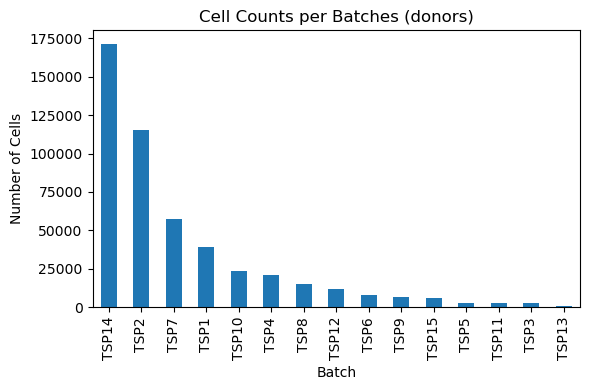

In [24]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (donors)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [25]:
def gini_py(values):
    """
    Compute the Gini coefficient of a list of non-negative numbers.
    Pure Python implementation (no NumPy).
    """
    values = list(values)

    if any(v < 0 for v in values):
        raise ValueError("All values must be non-negative.")

    if all(v == 0 for v in values):
        return 0.0

    # Sort values
    values.sort()
    n = len(values)
    total = sum(values)

    cumulative = 0
    weighted_sum = 0
    for i, v in enumerate(values, start=1):
        weighted_sum += (2 * i - n - 1) * v

    return weighted_sum / (n * total)

print(gini_py(batch_size))

0.6586153701802607
